# SmartBuild – Exploratory Data Analysis

**Consulting team analysis for SmartBuild (Task 1)**

Goal: understand the data measured *before* the machine (raw material + machine settings) and
the product properties measured *after*, so we can later predict:
- **Q1**: `weight_in_kg` (regression)
- **Q2**: `error` / `error_type` (classification)

Each section maps to a presentation slide. Story for the CEO/CTO:
1. The data has clear quality problems we must fix first.
2. Product weight is almost perfectly determined by one input (`width`).
3. **Defects (`error`) are almost perfectly predictable** from the raw material before the machine runs.
4. The *type* of defect (`error_type`) is essentially random — an honest negative result.
5. A simple defect predictor saves real money (150 EUR reject vs 10 EUR discard).

## 1. Setup, load and merge the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

In [2]:
#reading datasets
production_log = pd.read_csv('Production_Log_01.csv')
machine_settings_log =  pd.read_csv('Machine_Settings_Log_01.csv')

#merging production and machine settings
df = production_log.merge(machine_settings_log, on="configuration_log_ID", how="left")

print('Production log:', production_log.shape)
print('Machine settings log:', machine_settings_log.shape)
print('Merged:', df.shape)
df.head()

Production log: (10000, 20)
Machine settings log: (10000, 3)
Merged: (10000, 22)


,id,width,height,ionizationclass,FluxCompensation,pressure,karma,modulation,configuration_log_ID,weight_in_kg,weight_in_g,error,error_type,Quality,reflectionScore,distortion,nicesness,smartness,multideminsionality,roughness,gear,rotation_speed
0,1,137.419169,44.326218,C,IV,103.937207,976.538993,98.309438,1,837068.270898,8.370683e+08,no,NaN,95.489138,736.826681,49.666361,139.496837,2964.217002,no,123.202181,2,122.121415
1,2,98.706037,41.619531,A,II,101.177877,1031.806826,102.748068,2,435504.324849,4.355043e+08,no,NaN,98.262642,694.881024,52.826310,100.380138,2733.298369,yes,111.040858,1,111.977476
2,3,117.262568,41.421088,A,III,99.381956,840.246668,99.451354,3,599570.696236,5.995707e+08,no,NaN,98.472489,683.459298,51.967423,115.995772,2716.279965,no,138.439571,1,137.268544
3,4,122.657252,41.202308,A,I,101.833664,964.391122,101.022948,4,649889.744140,6.498897e+08,no,NaN,97.107023,699.626001,47.626823,121.383895,2694.883523,no,125.939831,2,125.719071
4,5,118.085366,43.418485,C,I,95.246304,859.331870,97.698503,5,605444.403997,6.054444e+08,no,NaN,92.994235,650.253900,47.420237,118.633440,2885.260257,no,135.123613,1,134.710713


### What is measured when?

To predict *before the machine is used* (as SmartBuild wants), we may only use inputs known **before** production. We group the columns explicitly so we never accidentally use a post-production property as a predictor.

In [3]:
# inputs measured on the raw material BEFORE the machine
raw_material_inputs = ['width', 'height', 'ionizationclass', 'FluxCompensation',
                       'pressure', 'karma', 'modulation']

# machine settings that are logged
machine_settings = ['gear', 'rotation_speed']

# properties of the final product measured AFTER the machine
product_outputs = ['weight_in_kg', 'weight_in_g', 'error', 'error_type', 'Quality',
                   'reflectionScore', 'distortion', 'nicesness', 'smartness',
                   'multideminsionality', 'roughness']

# features we are allowed to use for a 'predict before the machine runs' model
predictors = raw_material_inputs + machine_settings

print('Predictors (known before production):', predictors)
print('Targets / outputs (known only after):', product_outputs)

Predictors (known before production): ['width', 'height', 'ionizationclass', 'FluxCompensation', 'pressure', 'karma', 'modulation', 'gear', 'rotation_speed']
Targets / outputs (known only after): ['weight_in_kg', 'weight_in_g', 'error', 'error_type', 'Quality', 'reflectionScore', 'distortion', 'nicesness', 'smartness', 'multideminsionality', 'roughness']


## 2. Data overview

In [4]:
print('=== DTYPES ===')
print(df.dtypes)
print()
print('=== MISSING VALUES ===')
print(df.isna().sum()[df.isna().sum() > 0])

=== DTYPES ===
id                        int64
width                   float64
height                  float64
ionizationclass             str
FluxCompensation            str
pressure                float64
karma                   float64
modulation              float64
configuration_log_ID      int64
weight_in_kg            float64
weight_in_g             float64
error                       str
error_type                  str
Quality                 float64
reflectionScore         float64
distortion              float64
nicesness               float64
smartness               float64
multideminsionality         str
roughness               float64
gear                      int64
rotation_speed          float64
dtype: object

=== MISSING VALUES ===
error_type    6635
dtype: int64


In [5]:
# numeric summary
df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
id,5.000500e+03,2.886896e+03,1.000000e+00,1.000000e+04
width,2.000011e+07,4.467885e+08,3.086553e+01,1.000000e+10
height,4.200164e+01,2.015463e+00,3.509329e+01,4.932593e+01
pressure,9.977996e+01,5.424093e+00,-1.000000e+00,1.116290e+02
karma,9.988168e+02,9.881074e+01,6.639729e+02,1.348613e+03
modulation,1.000157e+02,2.991423e+00,8.829236e+01,1.108140e+02
configuration_log_ID,5.000500e+03,2.886896e+03,1.000000e+00,1.000000e+04
weight_in_kg,8.488496e+18,1.897801e+20,3.768185e+04,4.475432e+21
weight_in_g,8.488496e+21,1.897801e+23,3.768185e+07,4.475432e+24
Quality,9.660077e+01,4.786258e+00,-2.119128e+00,9.996952e+01


In [6]:
# categorical summary
for c in ['ionizationclass', 'FluxCompensation', 'error', 'error_type', 'multideminsionality']:
    print(c, '->', df[c].value_counts(dropna=False).to_dict())

ionizationclass -> {'A': 3347, 'B': 3345, 'C': 3308}
FluxCompensation -> {'IV': 2526, 'III': 2501, 'I': 2494, 'II': 2479}
error -> {'no': 6635, 'yes': 3365}
error_type -> {nan: 6635, 'critical': 1186, 'minor': 1097, 'severe': 1082}
multideminsionality -> {'yes': 5038, 'no': 4962}


**Observations**
- `error_type` is missing for exactly the products with `error == 'no'` — it only exists when there *is* an error. Not a data error, but we must handle it.
- The numeric `describe()` already shows impossible values: `width` max = 1e10, `weight_in_kg` max ~4e21, `pressure` min = -1, `Quality` min < 0. We investigate these next.

## 3. Data quality issues (pre-processing story)

Three distinct problems: (a) a redundant leakage column, (b) corrupted extreme outliers, (c) physically impossible negative values.

In [7]:
# (a) LEAKAGE: weight_in_g is just weight_in_kg * 1000 -> perfect but useless predictor
print('weight_in_g == 1000 * weight_in_kg ?',
      np.allclose(df['weight_in_g'], 1000 * df['weight_in_kg']))
print('-> weight_in_g must be DROPPED when predicting weight_in_kg (data leakage).')

weight_in_g == 1000 * weight_in_kg ? True
-> weight_in_g must be DROPPED when predicting weight_in_kg (data leakage).


In [8]:
# (b) CORRUPTED OUTLIERS in width and weight
print('width   > 1e6 :', (df['width'] > 1e6).sum(), 'rows | median =', round(df['width'].median(), 2))
print('weight  > 1e6 :', (df['weight_in_kg'] > 1e6).sum(), 'rows | median =', round(df['weight_in_kg'].median(), 2))

# (c) IMPOSSIBLE NEGATIVE / invalid values
print('pressure  < 0 :', (df['pressure'] < 0).sum(), 'rows')
print('Quality   < 0 :', (df['Quality'] < 0).sum(), 'rows')
print('reflectionScore < 0 :', (df['reflectionScore'] < 0).sum(), 'rows')

width   > 1e6 : 20 rows | median = 109.89
weight  > 1e6 : 177 rows | median = 517467.47
pressure  < 0 : 20 rows
Quality   < 0 : 20 rows
reflectionScore < 0 : 20 rows


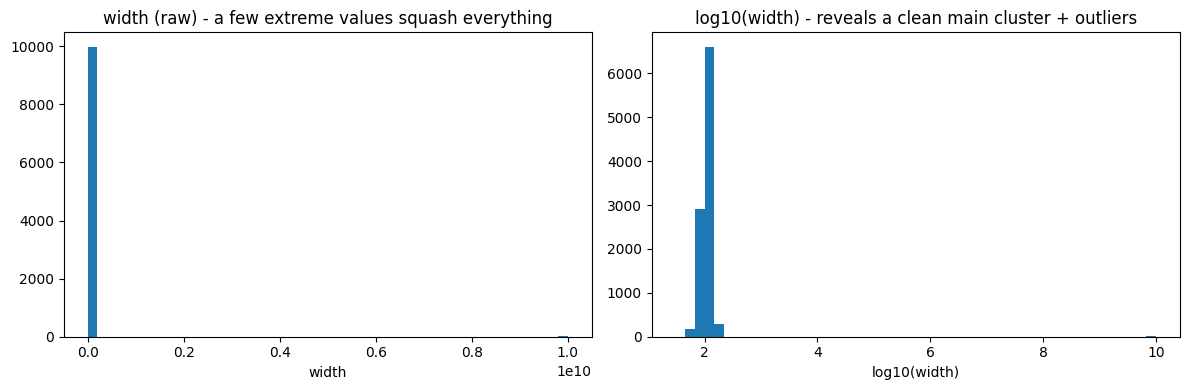

In [9]:
# visualise the corruption: raw width vs width on a log scale
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['width'], bins=50)
axes[0].set_title('width (raw) - a few extreme values squash everything')
axes[0].set_xlabel('width')

axes[1].hist(np.log10(df['width']), bins=50)
axes[1].set_title('log10(width) - reveals a clean main cluster + outliers')
axes[1].set_xlabel('log10(width)')
plt.tight_layout()
plt.show()

## 4. Cleaning

We build a cleaned copy: drop the leakage column, remove physically impossible values, and clip the corrupted extreme outliers. We keep the rule simple and explainable to the customer.

In [10]:
df_clean = df.copy()

# drop the leakage duplicate of the target
df_clean = df_clean.drop(columns=['weight_in_g'])

# remove impossible negative measurements
df_clean = df_clean[df_clean['pressure'] >= 0]
df_clean = df_clean[df_clean['Quality'] >= 0]

# remove corrupted extreme outliers (well above any realistic physical value)
df_clean = df_clean[df_clean['width'] < 1000]
df_clean = df_clean[df_clean['weight_in_kg'] < df_clean['weight_in_kg'].quantile(0.99)]

print('Original rows:', df.shape[0])
print('Cleaned rows :', df_clean.shape[0])
print('Removed      :', df.shape[0] - df_clean.shape[0])
df_clean[['width', 'weight_in_kg', 'pressure', 'Quality']].describe().T[['mean', 'std', 'min', 'max']]

Original rows: 10000
Cleaned rows : 9860
Removed      : 140


,mean,std,min,max
width,109.229726,19.494098,30.865527,1.635225e+02
weight_in_kg,526797.776230,179860.079299,37681.853424,1.046733e+06
pressure,99.979027,3.009822,89.049069,1.116290e+02
Quality,96.801315,1.901488,85.970489,9.996952e+01


## 5. Q1 exploration – what drives `weight_in_kg`?

We look for the inputs that correlate with product weight.

In [11]:
numeric_inputs = ['width', 'height', 'pressure', 'karma', 'modulation', 'gear', 'rotation_speed']
corr_with_weight = df_clean[numeric_inputs + ['weight_in_kg']].corr()['weight_in_kg'].sort_values()
print('Correlation of inputs with weight_in_kg:')
print(corr_with_weight.round(3))

Correlation of inputs with weight_in_kg:
pressure         -0.013
gear             -0.006
rotation_speed   -0.002
modulation        0.009
karma             0.010
height            0.117
width             0.980
weight_in_kg      1.000
Name: weight_in_kg, dtype: float64


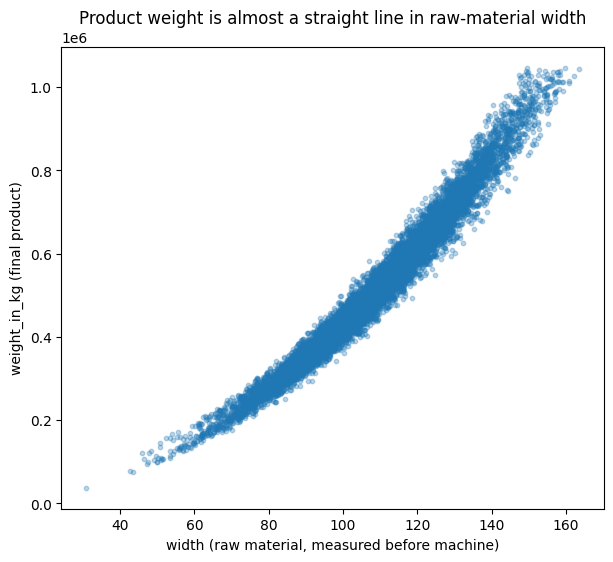

In [12]:
# width essentially determines weight
plt.figure(figsize=(7, 6))
plt.scatter(df_clean['width'], df_clean['weight_in_kg'], alpha=0.3, s=10)
plt.xlabel('width (raw material, measured before machine)')
plt.ylabel('weight_in_kg (final product)')
plt.title('Product weight is almost a straight line in raw-material width')
plt.show()

**Insight for Q1:** `weight_in_kg` is essentially a linear function of `width` (corr ~ 0.99). A simple linear regression will already give an excellent fit. The interesting part of Q1 is therefore the *pre-processing* (leakage + outliers), not the model complexity. See `linear_regression.py` / `polynomial_regression.py`.

## 6. Q2 exploration – what drives `error`? (the headline finding)

Overall about 1/3 of products are defective. We check whether any input known *before* the machine separates good from defective products.

In [13]:
print('Overall error rate:', round((df_clean['error'] == 'yes').mean(), 3))
print()
for col in ['ionizationclass', 'FluxCompensation', 'gear']:
    rates = df_clean.groupby(col)['error'].apply(lambda s: (s == 'yes').mean()).round(3)
    print(f'Error rate by {col}:')
    print(rates.to_string())
    print()

Overall error rate: 0.338

Error rate by ionizationclass:
ionizationclass
A    0.051
B    0.905
C    0.051

Error rate by FluxCompensation:
FluxCompensation
I      0.334
II     0.349
III    0.325
IV     0.343

Error rate by gear:
gear
1    0.335
2    0.340



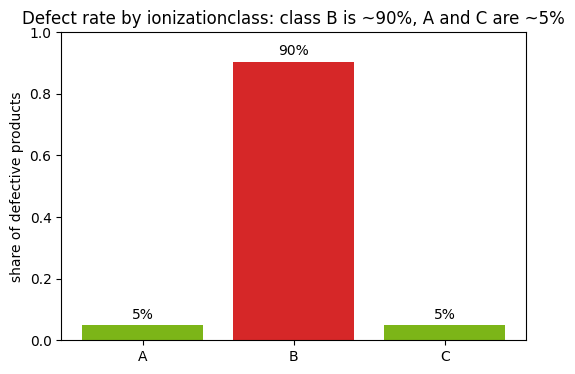

In [14]:
# visualise the dominant driver
rates = df_clean.groupby('ionizationclass')['error'].apply(lambda s: (s == 'yes').mean())
plt.figure(figsize=(6, 4))
plt.bar(rates.index, rates.values, color=['#7cb518', '#d62728', '#7cb518'])
plt.ylabel('share of defective products')
plt.title('Defect rate by ionizationclass: class B is ~90%, A and C are ~5%')
for i, v in enumerate(rates.values):
    plt.text(i, v + 0.02, f'{v:.0%}', ha='center')
plt.ylim(0, 1)
plt.show()

**Headline insight:** `ionizationclass == 'B'` is defective ~90% of the time, while classes A and C are defective only ~5%. Since `ionizationclass` is measured on the raw material **before** the machine runs, SmartBuild can predict (and avoid) most defects up front. `FluxCompensation` and `gear` carry essentially no signal (~33% each = the base rate).

## 7. Q2 `error_type` – an honest negative result

The task explicitly allows us to show that a good prediction is *not* possible. Among defective products, we check whether the *type* (critical / minor / severe) depends on any input.

In [15]:
errors_only = df_clean[df_clean['error'] == 'yes']
print('error_type distribution among defective products:')
print(errors_only['error_type'].value_counts(normalize=True).round(3))
print()
print('error_type vs ionizationclass (the strongest predictor we found):')
print(pd.crosstab(errors_only['ionizationclass'], errors_only['error_type'], normalize='index').round(3))

error_type distribution among defective products:
error_type
critical    0.354
minor       0.326
severe      0.321
Name: proportion, dtype: float64

error_type vs ionizationclass (the strongest predictor we found):
error_type       critical  minor  severe
ionizationclass                         
A                   0.365  0.323   0.311
B                   0.351  0.328   0.321
C                   0.386  0.289   0.325


**Insight:** the three error types are split roughly 1/3 each, and that split does **not** change with `ionizationclass` (or the other inputs). So we can predict *whether* a product fails, but not *which* failure type — a clean contrast to present: an easy problem (`error`) next to an impossible one (`error_type`).

## 8. Cost analysis – what is this worth to SmartBuild?

From the task: a faulty product costs **150 EUR**, discarding raw material costs **10 EUR**.
A naive policy ('produce everything') pays 150 EUR for every defect. A simple rule based on our
finding ('discard class-B raw material before production') trades a 10 EUR discard for avoiding
the 150 EUR reject on most of those units.

In [16]:
# ----------------------------------------------------------------------
# Cost figures given by SmartBuild (Task slide 10)
# ----------------------------------------------------------------------
COST_FAULTY  = 150   # EUR, a faulty product (machine use + raw material)
COST_DISCARD = 10    # EUR, discard the raw material before production

n       = len(df_clean)                       # units in the (cleaned) data
defects = (df_clean['error'] == 'yes').sum()  # how many are defective

# ----------------------------------------------------------------------
# STEP 1 - how bad is it today?  (the 33.8% figure)
# ----------------------------------------------------------------------
defect_rate = defects / n
print('STEP 1  current state')
print(f'  units                 : {n}')
print(f'  defects               : {defects}')
print(f'  defect rate           : {defect_rate:.3f}  ->  {defect_rate*100:.1f}%')
print()

# ----------------------------------------------------------------------
# STEP 2 - Policy A baseline: 'produce everything' (the 50.64 EUR/unit)
#          Every defect costs 150 EUR; we spread that over ALL units.
# ----------------------------------------------------------------------
cost_produce_all     = defects * COST_FAULTY          # total EUR
cost_per_unit_A      = cost_produce_all / n           # EUR per unit produced
print('STEP 2  Policy A - produce everything (do nothing)')
print(f'  total defect cost     : {cost_produce_all:,.0f} EUR  (= {defects} x {COST_FAULTY})')
print(f'  cost per unit         : {cost_per_unit_A:.2f} EUR')
print(f'  cross-check           : defect_rate x 150 = {defect_rate*COST_FAULTY:.2f} EUR  (same number)')
print()

# ----------------------------------------------------------------------
# STEP 3 - Policy B: screen out class-B raw material BEFORE production
#          Class B = the input that is defective ~90% of the time.
#          We pay 10 EUR to discard each B unit; the remaining (non-B)
#          units we still produce, and some of those still fail (150 EUR).
# ----------------------------------------------------------------------
is_B              = df_clean['ionizationclass'] == 'B'
discarded         = is_B.sum()                                   # class-B units discarded
remaining_defects = ((~is_B) & (df_clean['error'] == 'yes')).sum()  # defects we still make
cost_discard_B    = discarded * COST_DISCARD + remaining_defects * COST_FAULTY
cost_per_unit_B   = cost_discard_B / n
print('STEP 3  Policy B - discard class-B raw material first')
print(f'  class-B units discarded : {discarded}   (x {COST_DISCARD} EUR)')
print(f'  non-B defects still made: {remaining_defects}   (x {COST_FAULTY} EUR)')
print(f'  total cost            : {cost_discard_B:,.0f} EUR')
print(f'  cost per unit         : {cost_per_unit_B:.2f} EUR')
print()

# ----------------------------------------------------------------------
# STEP 4 - the saving (per unit, total, and as a %)
# ----------------------------------------------------------------------
saving_total    = cost_produce_all - cost_discard_B
saving_per_unit = cost_per_unit_A - cost_per_unit_B
saving_pct      = saving_total / cost_produce_all
print('STEP 4  saving of Policy B vs Policy A')
print(f'  per unit              : {cost_per_unit_A:.2f}  ->  {cost_per_unit_B:.2f} EUR   (save {saving_per_unit:.2f} EUR/unit)')
print(f'  total (this sample)   : {saving_total:,.0f} EUR')
print(f'  reduction             : {saving_pct:.0%}')
print()

# ----------------------------------------------------------------------
# STEP 5 - scale to a yearly volume (state this as an ASSUMPTION)
# ----------------------------------------------------------------------
ANNUAL_UNITS = 100_000
saving_per_year = saving_per_unit * ANNUAL_UNITS
print(f'STEP 5  extrapolation (assumption: {ANNUAL_UNITS:,} units / year)')
print(f'  estimated saving      : ~{saving_per_year:,.0f} EUR / year')

STEP 1  current state
  units                 : 9860
  defects               : 3329
  defect rate           : 0.338  ->  33.8%

STEP 2  Policy A - produce everything (do nothing)
  total defect cost     : 499,350 EUR  (= 3329 x 150)
  cost per unit         : 50.64 EUR
  cross-check           : defect_rate x 150 = 50.64 EUR  (same number)

STEP 3  Policy B - discard class-B raw material first
  class-B units discarded : 3311   (x 10 EUR)
  non-B defects still made: 333   (x 150 EUR)
  total cost            : 83,060 EUR
  cost per unit         : 8.42 EUR

STEP 4  saving of Policy B vs Policy A
  per unit              : 50.64  ->  8.42 EUR   (save 42.22 EUR/unit)
  total (this sample)   : 416,290 EUR
  reduction             : 83%

STEP 5  extrapolation (assumption: 100,000 units / year)
  estimated saving      : ~4,222,008 EUR / year


### How the headline numbers are derived (for the presentation discussion)

The five steps above make every slide number reproducible:

| Number | Formula | Result |
|---|---|---|
| **Defect rate** | `defects / n` | **33.8 %** |
| **Baseline cost / unit** (Policy A) | `defects x 150 / n`  = `defect_rate x 150` | **50.64 EUR** |
| **Cost / unit with screening** (Policy B) | `(discarded x 10 + remaining_defects x 150) / n` | **8.42 EUR** |
| **Saving / unit** | `cost_per_unit_A - cost_per_unit_B` | **~42 EUR** |
| **Reduction** | `saving_total / cost_produce_all` | **83 %** |
| **Annual saving** | `saving_per_unit x 100,000` (assumed volume) | **~4.2 M EUR** |

**Important honesty notes (be ready for CEO/CTO questions):**
- `50.64 EUR/unit` is the 150 EUR reject penalty *averaged over every unit produced*, not the price of one product. It is the right baseline because Policy B is averaged the same way, so the **42 EUR/unit difference is a like-for-like comparison**.
- The model only counts the 150 EUR / 10 EUR figures given in the task; it ignores normal production cost and assumes the data's 33.8 % rate reflects real operations.
- The yearly figure is a linear extrapolation from the 9,860-unit sample to an **assumed** 100,000 units/year — adjust `ANNUAL_UNITS` to SmartBuild's real volume.

This is the number to put in front of the CEO/CTO: even a one-rule policy derived from a single
input measured before production avoids a large share of the 150 EUR rejects. A trained classifier
(see the modelling scripts) can refine this further.

## 9. Quick scan of the other product properties (ideas for the per-person analyses)

Each group member needs >= 2 analyses. Here we check which *other* outputs are predictable from the
inputs, to pick promising targets (e.g. reflectionScore, smartness, roughness).

In [17]:
other_targets = ['Quality', 'reflectionScore', 'distortion', 'smartness', 'roughness']
print('Max |correlation| of each output with any numeric input:')
for t in other_targets:
    cors = df_clean[numeric_inputs + [t]].corr()[t].drop(t).abs()
    best = cors.idxmax()
    print(f'  {t:<16} best input = {best:<14} |corr| = {cors.max():.3f}')

Max |correlation| of each output with any numeric input:
  Quality          best input = pressure       |corr| = 0.022
  reflectionScore  best input = pressure       |corr| = 0.900
  distortion       best input = modulation     |corr| = 0.008
  smartness        best input = height         |corr| = 0.999
  roughness        best input = rotation_speed |corr| = 0.995


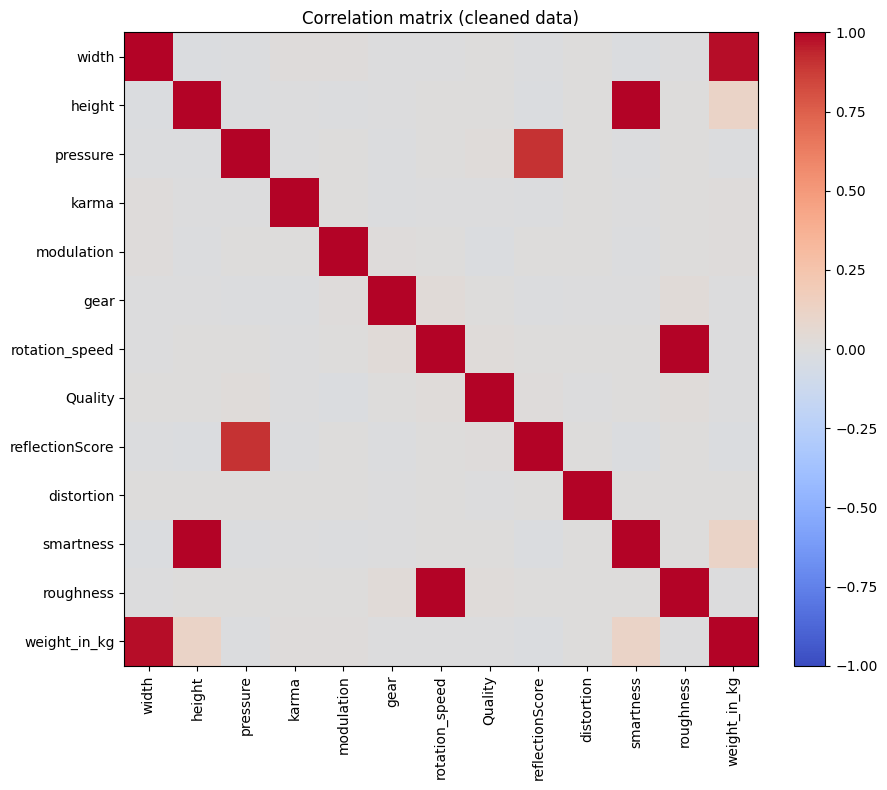

In [18]:
# correlation heatmap of numeric inputs and outputs
cols = numeric_inputs + other_targets + ['weight_in_kg']
corr = df_clean[cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90)
ax.set_yticklabels(cols)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation matrix (cleaned data)')
plt.tight_layout()
plt.show()

**Per-person analysis ideas (from the scan above):** `smartness` ~ `height`, `roughness` ~ `rotation_speed`, and `reflectionScore` ~ `pressure` are all strongly predictable (|corr| ~ 0.9+), while `Quality` and `distortion` look like noise. A nice contrast: present one easy regression next to one that proves prediction is not possible.

## 9a. Correlation matrix (slide format)

Following the lecture's "Code to Analyze Correlation" template: compute one `df.corr()` and print the full matrix. Two adaptations are forced by our data: (1) we run it on the **cleaned** `df_clean`, because the raw corruption would dominate every coefficient, and (2) a Pearson matrix only covers numeric columns — the categorical drivers get their own measure in 9b.

In [ ]:
# ---------------------------------------------------------------
# Full numeric correlation matrix (mirrors the lecture template,
# but on the CLEANED data df_clean -- NOT raw df. On raw df the
# width/weight corruption (1e10, 1e21) destroys every correlation.)
# ---------------------------------------------------------------
numeric_cols = ['width', 'height', 'pressure', 'karma', 'modulation',
                'gear', 'rotation_speed',
                'weight_in_kg', 'Quality', 'reflectionScore',
                'distortion', 'smartness', 'roughness']

corr_matrix = df_clean[numeric_cols].corr()

# make sure the whole matrix prints (same intent as the slide's display options)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 10000)
pd.set_option('display.max_rows', None)

print('Numeric correlation matrix (cleaned data):')
print(corr_matrix.round(3))

### 9b. Categorical drivers — Cramér's V

A numeric correlation matrix silently ignores the categorical columns (`ionizationclass`, `FluxCompensation`, `error`, ...), yet that is exactly where our headline lives. **Cramér's V** gives the same "one number per pair, 0–1" feel as a correlation, but for categorical-vs-categorical relationships. We expect `ionizationclass` ↔ `error` to stand out (~0.8–0.9) while everything else stays near 0.

In [ ]:
from scipy.stats import chi2_contingency

# Cramér's V: a 0..1 association measure for two CATEGORICAL columns.
# (Pearson .corr() above can only see numeric columns, so the strongest
#  signal in this dataset -- ionizationclass -> error -- is invisible there.)
def cramers_v(a, b):
    ct = pd.crosstab(a, b)
    chi2 = chi2_contingency(ct)[0]
    n = ct.to_numpy().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

cat_cols = ['ionizationclass', 'FluxCompensation', 'multideminsionality',
            'gear', 'error']

cat_assoc = pd.DataFrame(
    [[cramers_v(df_clean[i], df_clean[j]) for j in cat_cols] for i in cat_cols],
    index=cat_cols, columns=cat_cols)

print('Cramers V association between categorical columns (0 = none, 1 = perfect):')
print(cat_assoc.round(3))

## 10. Summary of insights for SmartBuild (CEO/CTO)

1. **Data quality first.** The logs contain a leakage column (`weight_in_g` = 1000x`weight_in_kg`), corrupted extreme outliers in `width`/`weight`, and impossible negative `pressure`/`Quality`. Cleaning these is a prerequisite for any reliable model.
2. **Q1 – weight is easy.** `weight_in_kg` is an almost perfect linear function of raw-material `width`. A simple model predicts it well; the value is in the clean pipeline, not model complexity.
3. **Q2 – defects are predictable before production.** `ionizationclass = B` raw material fails ~90% of the time vs ~5% for A/C. This is measurable *before* the machine runs.
4. **Q2 – defect *type* is not predictable.** critical/minor/severe are ~1/3 each regardless of inputs — an honest limitation.
5. **Business value.** A one-rule 'discard class-B input' policy already avoids a large share of 150 EUR rejects (see section 8). This is the headline recommendation.

**Next steps / if we had more time:** train and compare proper classifiers for `error` (logistic regression, decision tree, gradient boosting), tune the discard threshold against the 150/10 EUR cost, and investigate whether `width`/`nicesness` are genuinely independent sensors or a duplicated measurement.